# US Revenue Forecast 결과 조회

ticker, forecast_date, indicator를 입력받아 해당 데이터를 조회 및 출력하는 노트북입니다.

## 1. 라이브러리 임포트 및 설정

In [1]:
import sys
import pandas as pd
from datetime import datetime
from sqlalchemy import create_engine, text
import warnings
from DATA.stock_invest_function import get_db_host

warnings.filterwarnings('ignore')

print("✓ 라이브러리 임포트 완료")


✓ 라이브러리 임포트 완료


## 2. DB 연결 설정

아래 셀에서 DB 연결 정보를 수정하세요.

In [2]:
# DB 연결 정보 설정
db_config = {
    'host': get_db_host(),  # 실행 시 get_db_host()로 설정
    'port': 3307,
    'user': 'stox7412',
    'password': 'Apt106503!~',
    'database': 'investar'
}

print("✓ DB 설정 완료")
print(f"  Host: {db_config['host']}:{db_config['port']}")
print(f"  Database: {db_config['database']}")

✓ DB 설정 완료
  Host: 192.168.0.230:3307
  Database: investar


## 3. RevenueForecastViewer 클래스 정의

In [3]:
class RevenueForecastViewer:
    """Revenue Forecast 데이터 조회 클래스"""

    def __init__(self, db_config):
        """
        Args:
            db_config: DB 연결 정보 딕셔너리
                - host, port, database, user, password
        """
        self.db_config = db_config
        self.engine = None
        self._connect_db()

    def _connect_db(self):
        """DB 연결"""
        try:
            conn_str = (
                f"mysql+pymysql://{self.db_config['user']}:{self.db_config['password']}@"
                f"{self.db_config['host']}:{self.db_config['port']}/"
                f"{self.db_config['database']}?charset=utf8mb4"
            )
            self.engine = create_engine(conn_str)
            print(f"✓ DB 연결 성공: {self.db_config['host']}:{self.db_config['port']}/{self.db_config['database']}")
        except Exception as e:
            print(f"✗ DB 연결 실패: {e}")
            raise

    def get_available_tickers(self):
        """사용 가능한 ticker 목록 조회"""
        query = """
        SELECT DISTINCT ticker
        FROM us_revenue_forecast_result
        ORDER BY ticker
        """
        try:
            with self.engine.connect() as conn:
                df = pd.read_sql(query, conn)
            return df['ticker'].tolist()
        except Exception as e:
            print(f"✗ Ticker 목록 조회 실패: {e}")
            return []

    def get_available_forecast_dates(self, ticker=None):
        """사용 가능한 forecast_date 목록 조회"""
        if ticker:
            query = """
            SELECT DISTINCT forecast_date
            FROM us_revenue_forecast_result
            WHERE ticker = :ticker
            ORDER BY forecast_date DESC
            """
            params = {'ticker': ticker}
        else:
            query = """
            SELECT DISTINCT forecast_date
            FROM us_revenue_forecast_result
            ORDER BY forecast_date DESC
            """
            params = {}

        try:
            with self.engine.connect() as conn:
                if params:
                    df = pd.read_sql(text(query), conn, params=params)
                else:
                    df = pd.read_sql(query, conn)
            return df['forecast_date'].tolist()
        except Exception as e:
            print(f"✗ Forecast date 목록 조회 실패: {e}")
            return []

    def get_available_indicators(self, ticker=None, forecast_date=None):
        """사용 가능한 indicator 목록 조회"""
        conditions = []
        params = {}

        if ticker:
            conditions.append("ticker = :ticker")
            params['ticker'] = ticker
        if forecast_date:
            conditions.append("forecast_date = :forecast_date")
            params['forecast_date'] = forecast_date

        where_clause = " WHERE " + " AND ".join(conditions) if conditions else ""

        query = f"""
        SELECT DISTINCT indicator
        FROM us_revenue_forecast_result
        {where_clause}
        ORDER BY indicator
        """

        try:
            with self.engine.connect() as conn:
                if params:
                    df = pd.read_sql(text(query), conn, params=params)
                else:
                    df = pd.read_sql(query, conn)
            return df['indicator'].tolist()
        except Exception as e:
            print(f"✗ Indicator 목록 조회 실패: {e}")
            return []

    def query_revenue_forecast(self, ticker, forecast_date, indicator=None):
        """
        Revenue forecast 데이터 조회

        Args:
            ticker: 종목 코드
            forecast_date: 예측 날짜 (YYYY-MM-DD)
            indicator: 지표명 (None이면 모든 지표)

        Returns:
            DataFrame
        """
        conditions = ["ticker = :ticker", "forecast_date = :forecast_date"]
        params = {'ticker': ticker, 'forecast_date': forecast_date}

        if indicator:
            conditions.append("indicator = :indicator")
            params['indicator'] = indicator

        where_clause = " AND ".join(conditions)

        query = f"""
        SELECT
            date,
            ticker,
            indicator,
            value,
            forecast_date,
            created_at,
            updated_at
        FROM us_revenue_forecast_result
        WHERE {where_clause}
        ORDER BY date, indicator
        """

        try:
            with self.engine.connect() as conn:
                df = pd.read_sql(text(query), conn, params=params)

            if df.empty:
                print(f"⚠ 조회된 데이터가 없습니다.")
                return df

            # 날짜 형식 변환
            df['date'] = pd.to_datetime(df['date'])
            df['forecast_date'] = pd.to_datetime(df['forecast_date'])

            return df

        except Exception as e:
            print(f"✗ 데이터 조회 실패: {e}")
            return pd.DataFrame()

    def display_results(self, df, output_format='wide'):
        """
        조회 결과 출력

        Args:
            df: 조회된 DataFrame
            output_format: 'wide' (pivot 테이블) 또는 'long' (원본 형태)
        """
        if df.empty:
            return

        print("\n" + "=" * 100)
        print(f"조회 결과: {len(df)} rows")
        print("=" * 100)

        if output_format == 'wide':
            # Wide format (indicator별로 컬럼 분리)
            pivot_df = df.pivot_table(
                index='date',
                columns='indicator',
                values='value',
                aggfunc='first'
            )
            pivot_df.index = pivot_df.index.strftime('%Y-%m-%d')

            print("\n[Wide Format - Pivot Table]")
            display(pivot_df)

            # 통계 정보
            print("\n[통계 정보]")
            display(pivot_df.describe())

        else:
            # Long format (원본)
            print("\n[Long Format - Original Data]")
            display_df = df.copy()
            display_df['date'] = display_df['date'].dt.strftime('%Y-%m-%d')
            display_df['forecast_date'] = display_df['forecast_date'].dt.strftime('%Y-%m-%d')
            display(display_df)

        # 메타 정보
        print("\n" + "-" * 100)
        print(f"Ticker: {df['ticker'].iloc[0]}")
        print(f"Forecast Date: {df['forecast_date'].iloc[0].strftime('%Y-%m-%d')}")
        print(f"Date Range: {df['date'].min().strftime('%Y-%m-%d')} ~ {df['date'].max().strftime('%Y-%m-%d')}")
        print(f"Indicators: {', '.join(df['indicator'].unique())}")
        print("=" * 100)

    def save_to_csv(self, df, filename=None):
        """결과를 CSV 파일로 저장"""
        if df.empty:
            return

        if filename is None:
            ticker = df['ticker'].iloc[0]
            forecast_date = df['forecast_date'].iloc[0].strftime('%Y%m%d')
            filename = f"revenue_forecast_{ticker}_{forecast_date}.csv"

        try:
            df.to_csv(filename, index=False, encoding='utf-8-sig')
            print(f"\n✓ CSV 파일 저장 완료: {filename}")
        except Exception as e:
            print(f"\n✗ CSV 파일 저장 실패: {e}")

print("✓ RevenueForecastViewer 클래스 정의 완료")

✓ RevenueForecastViewer 클래스 정의 완료


## 4. Viewer 초기화

In [4]:
# Viewer 객체 생성
viewer = RevenueForecastViewer(db_config)

✓ DB 연결 성공: 192.168.0.230:3307/investar


## 5. 사용 가능한 데이터 목록 조회

### 5.1 Ticker 목록

In [5]:
# 사용 가능한 ticker 목록 조회
tickers = viewer.get_available_tickers()
print(f"\n사용 가능한 Ticker: {len(tickers)}개")
print("-" * 50)
print(tickers[:20])  # 처음 20개만 출력


사용 가능한 Ticker: 844개
--------------------------------------------------
['A', 'AAP', 'AAPL', 'ABBV', 'ABG', 'ABM', 'ABNB', 'ABT', 'ACA', 'ACAD', 'ACHC', 'ACIW', 'ACLS', 'ACMR', 'ACN', 'ACT', 'ADBE', 'ADEA', 'ADI', 'ADM']


### 5.2 Forecast Date 목록

In [6]:
# 사용 가능한 forecast_date 목록 조회
dates = viewer.get_available_forecast_dates()
print(f"\n사용 가능한 Forecast Date: {len(dates)}개")
print("-" * 50)
for date in dates:
    print(date)


사용 가능한 Forecast Date: 3개
--------------------------------------------------
2025-11-06
2025-11-04
2025-11-02


### 5.3 Indicator 목록

In [7]:
# 사용 가능한 indicator 목록 조회
indicators = viewer.get_available_indicators()
print(f"\n사용 가능한 Indicator: {len(indicators)}개")
print("-" * 50)
for i, indicator in enumerate(indicators, 1):
    print(f"{i:2d}. {indicator}")


사용 가능한 Indicator: 4개
--------------------------------------------------
 1. revenue_billions_esq_forecast
 2. revenue_billions_lstm_forecast
 3. revenue_billions_prophet_forecast
 4. revenue_billions_sarima_noexog


## 6. 데이터 조회

### 6.1 기본 조회 (모든 지표)

In [38]:
# 조회할 ticker와 forecast_date 설정
ticker = 'MU'              # 여기를 원하는 ticker로 수정
forecast_date = '2025-11-06'  # 여기를 원하는 날짜로 수정

# 데이터 조회
df = viewer.query_revenue_forecast(ticker, forecast_date)

# 결과 출력 (Wide format)
if not df.empty:
    viewer.display_results(df, output_format='wide')


조회 결과: 256 rows

[Wide Format - Pivot Table]


indicator,revenue_billions_esq_forecast,revenue_billions_lstm_forecast,revenue_billions_prophet_forecast,revenue_billions_sarima_noexog
date,,,,
2015-02-28,4.166000,4.166000,4.166000,4.166000
2015-03-31,NaN,4.170000,4.170000,4.170000
2015-05-31,3.853000,3.853000,3.853000,3.853000
2015-06-30,NaN,3.850000,3.850000,3.850000
2015-08-31,3.600000,NaN,3.600000,3.600000
...,...,...,...,...
2026-02-28,14.380129,4.935554,7.743356,11.345643
2026-05-31,15.915193,4.805113,8.118264,11.872698
2026-08-31,17.450258,4.519616,8.344816,12.306848



[통계 정보]


indicator,revenue_billions_esq_forecast,revenue_billions_lstm_forecast,revenue_billions_prophet_forecast,revenue_billions_sarima_noexog
count,47.000000,67.000000,70.000000,72.000000
mean,6.737078,5.758295,5.856724,6.236358
std,3.263599,1.925118,1.997490,2.557893
min,2.898000,2.898000,2.898000,2.898000
25%,4.407000,4.082500,3.980000,4.000000
50%,6.056000,5.570000,5.796500,5.825000
75%,7.855000,7.421000,7.730017,7.787000
max,17.450258,11.310000,11.310000,12.306848



----------------------------------------------------------------------------------------------------
Ticker: MU
Forecast Date: 2025-11-06
Date Range: 2015-02-28 ~ 2027-02-28
Indicators: revenue_billions_esq_forecast, revenue_billions_lstm_forecast, revenue_billions_prophet_forecast, revenue_billions_sarima_noexog


### 6.2 특정 지표만 조회

In [40]:
# 조회할 ticker, forecast_date, indicator 설정
ticker = 'MU'
forecast_date = '2025-11-06'
indicator = 'revenue_billions_sarima_noexog'  # 원하는 지표로 수정

# 데이터 조회
df = viewer.query_revenue_forecast(ticker, forecast_date, indicator)

# 결과 출력 (Long format)
if not df.empty:
    viewer.display_results(df, output_format='long')


조회 결과: 72 rows

[Long Format - Original Data]


,date,ticker,indicator,value,forecast_date,created_at,updated_at
0,2015-02-28,MU,revenue_billions_sarima_noexog,4.166000,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42
1,2015-03-31,MU,revenue_billions_sarima_noexog,4.170000,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42
2,2015-05-31,MU,revenue_billions_sarima_noexog,3.853000,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42
3,2015-06-30,MU,revenue_billions_sarima_noexog,3.850000,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42
4,2015-08-31,MU,revenue_billions_sarima_noexog,3.600000,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42
...,...,...,...,...,...,...,...
67,2026-02-28,MU,revenue_billions_sarima_noexog,11.345643,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42
68,2026-05-31,MU,revenue_billions_sarima_noexog,11.872698,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42
69,2026-08-31,MU,revenue_billions_sarima_noexog,12.306848,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42
70,2026-11-30,MU,revenue_billions_sarima_noexog,12.243266,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42



----------------------------------------------------------------------------------------------------
Ticker: MU
Forecast Date: 2025-11-06
Date Range: 2015-02-28 ~ 2027-02-28
Indicators: revenue_billions_sarima_noexog


In [41]:
df.tail(24)

,date,ticker,indicator,value,forecast_date,created_at,updated_at
48,2022-06-30,MU,revenue_billions_sarima_noexog,8.640000,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42
49,2022-08-31,MU,revenue_billions_sarima_noexog,6.643000,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42
50,2022-09-30,MU,revenue_billions_sarima_noexog,6.640000,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42
51,2022-11-30,MU,revenue_billions_sarima_noexog,4.085000,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42
52,2022-12-31,MU,revenue_billions_sarima_noexog,4.080000,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42
53,2023-02-28,MU,revenue_billions_sarima_noexog,3.693000,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42
54,2023-03-31,MU,revenue_billions_sarima_noexog,3.690000,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42
55,2023-05-31,MU,revenue_billions_sarima_noexog,3.752000,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42
56,2023-06-30,MU,revenue_billions_sarima_noexog,3.750000,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42
57,2023-08-31,MU,revenue_billions_sarima_noexog,4.010000,2025-11-06,2025-11-06 13:58:42,2025-11-06 13:58:42


### 6.3 특정 ticker의 사용 가능한 날짜 확인

In [ ]:
# 특정 ticker의 forecast_date 목록
ticker = 'AAPL'
dates = viewer.get_available_forecast_dates(ticker)
print(f"\n{ticker}의 사용 가능한 Forecast Date: {len(dates)}개")
print("-" * 50)
for date in dates:
    print(date)

## 7. CSV 파일로 저장

In [ ]:
# 데이터 조회 및 CSV 저장
ticker = 'AAPL'
forecast_date = '2025-11-06'

df = viewer.query_revenue_forecast(ticker, forecast_date)

if not df.empty:
    # 자동 파일명으로 저장
    viewer.save_to_csv(df)

    # 또는 커스텀 파일명으로 저장
    # viewer.save_to_csv(df, "my_revenue_data.csv")

## 8. 여러 Ticker 비교

In [11]:
# 여러 ticker의 평균 매출 예측 비교
tickers = ['AAPL', 'GOOGL', 'MSFT']  # 비교할 ticker 리스트
forecast_date = '2025-11-06'
indicator = 'revenue_billions_sarima_noexog'

results = {}

for ticker in tickers:
    df = viewer.query_revenue_forecast(ticker, forecast_date, indicator)
    if not df.empty:
        results[ticker] = df

if results:
    print("\n" + "=" * 80)
    print("여러 Ticker 비교 - 평균 매출 예측 (TTM)")
    print("=" * 80)

    comparison_data = []
    for ticker, df in results.items():
        avg_value = df['value'].mean()
        max_value = df['value'].max()
        min_value = df['value'].min()
        comparison_data.append({
            'Ticker': ticker,
            '평균': avg_value,
            '최대': max_value,
            '최소': min_value
        })

    comparison_df = pd.DataFrame(comparison_data)
    display(comparison_df)


여러 Ticker 비교 - 평균 매출 예측 (TTM)


,Ticker,평균,최대,최소
0,AAPL,81.630626,138.148487,42.36
1,GOOGL,59.926617,125.386843,17.26
2,MSFT,47.224613,93.265918,20.38


## 9. 시계열 분석

In [12]:
# 시계열 분석 및 성장률 계산
ticker = 'AAPL'
forecast_date = '2025-11-06'

df = viewer.query_revenue_forecast(ticker, forecast_date)

if not df.empty:
    # Wide format으로 변환
    pivot_df = df.pivot_table(
        index='date',
        columns='indicator',
        values='value',
        aggfunc='first'
    )

    print("\n" + "=" * 80)
    print(f"{ticker} 월별 성장률 분석")
    print("=" * 80)

    growth_data = []

    # 각 지표별 성장률 계산
    for col in pivot_df.columns:
        if len(pivot_df) > 1:
            # 연평균 성장률 (CAGR)
            first_value = pivot_df[col].iloc[0]
            last_value = pivot_df[col].iloc[-1]
            periods = len(pivot_df)

            if first_value > 0:
                cagr = ((last_value / first_value) ** (1/periods) - 1) * 100
                growth_data.append({
                    'Indicator': col,
                    '시작값': first_value,
                    '종료값': last_value,
                    '월평균 성장률(%)': cagr
                })

    growth_df = pd.DataFrame(growth_data)
    display(growth_df)


AAPL 월별 성장률 분석


,Indicator,시작값,종료값,월평균 성장률(%)
0,revenue_billions_esq_forecast,58.01,NaN,NaN
1,revenue_billions_lstm_forecast,58.01,NaN,NaN
2,revenue_billions_prophet_forecast,58.01,NaN,NaN
3,revenue_billions_sarima_noexog,58.01,111.50652,1.24059


## 10. 시각화 (선택사항)

matplotlib을 사용한 간단한 시각화 예제

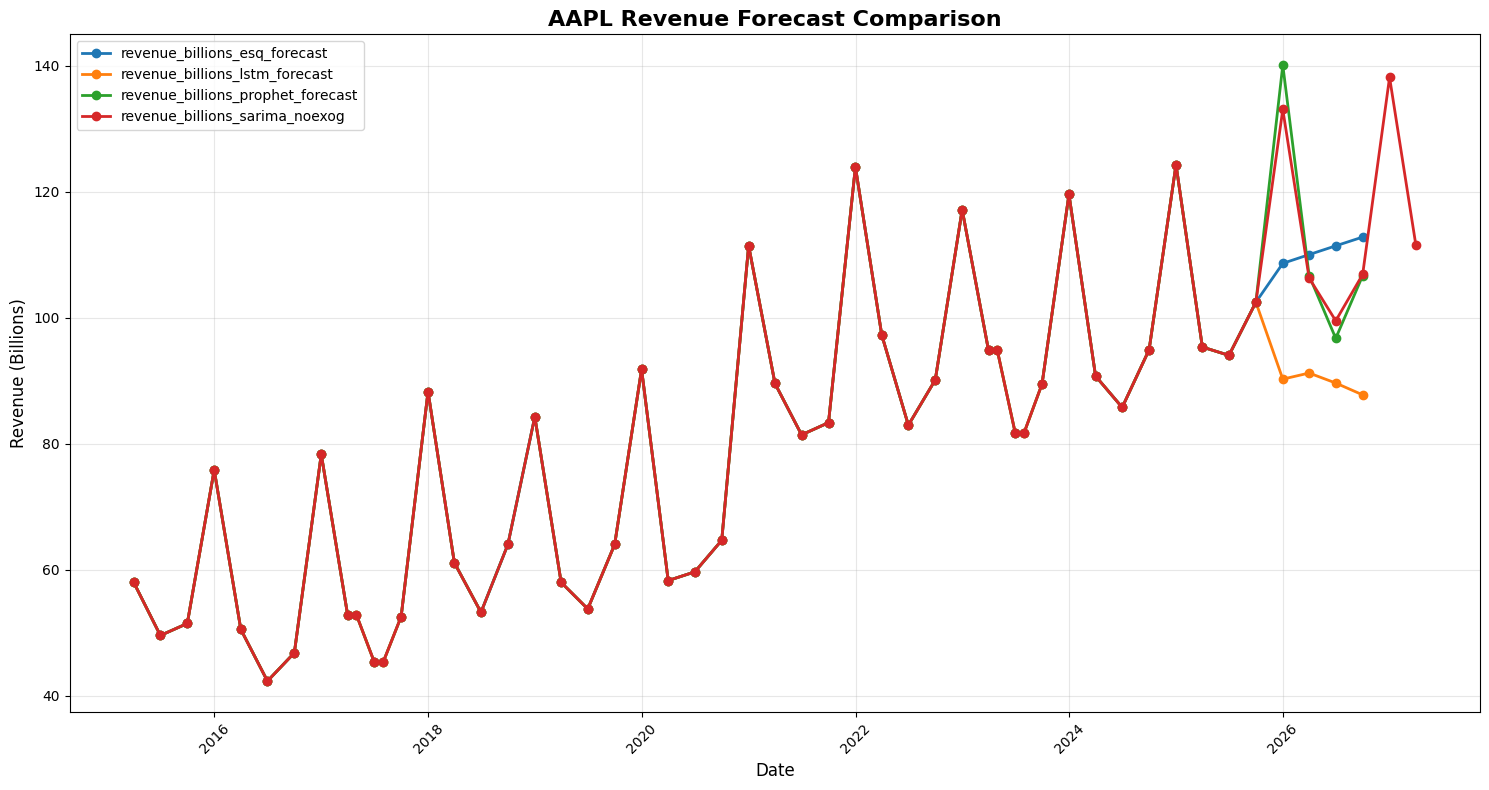

In [13]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정 (선택사항)
# plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'AppleGothic'    # Mac
plt.rcParams['axes.unicode_minus'] = False

# 데이터 조회
ticker = 'AAPL'
forecast_date = '2025-11-06'

df = viewer.query_revenue_forecast(ticker, forecast_date)

if not df.empty:
    # Wide format으로 변환
    pivot_df = df.pivot_table(
        index='date',
        columns='indicator',
        values='value',
        aggfunc='first'
    )

    # 그래프 그리기
    plt.figure(figsize=(15, 8))

    for col in pivot_df.columns:
        plt.plot(pivot_df.index, pivot_df[col], marker='o', label=col, linewidth=2)

    plt.title(f'{ticker} Revenue Forecast Comparison', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Revenue (Billions)', fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 사용 팁

### 주요 Indicator 종류
- `revenue_billions_sarima_noexog`: SARIMA 모델 예측
- `revenue_billions_lstm_forecast`: LSTM 모델 예측
- `revenue_billions_prophet_forecast`: Prophet 모델 예측
- `revenue_billions_esq_forecast`: Exponential Smoothing 예측
- `revenue_billions_avg_of_4_ttm`: 4개 모델 평균 TTM

### 일반적인 사용 흐름
1. 섹션 1-4: 초기 설정 및 DB 연결
2. 섹션 5: 사용 가능한 데이터 확인
3. 섹션 6: 필요한 데이터 조회
4. 섹션 7-10: 추가 분석 및 시각화

### 수정이 필요한 부분
- **섹션 2**: DB 연결 정보 (host, port, database, user, password)
- **섹션 6**: ticker와 forecast_date를 원하는 값으로 변경
- **섹션 8**: 비교할 ticker 리스트 수정
- **섹션 10**: 폰트 설정 (한글 사용 시)